# Load dataset

In [1]:
from temporal.load_data_temp import load_temporal_images

In [2]:
base_path_temporal = "data/Fotos_temporales/"
temporal_dataset = load_temporal_images(base_path_temporal)

## Check dataset

In [3]:
for time_label, groups in temporal_dataset.items():
    for group, imgs in groups.items():
        print(f"{time_label:>4} | {group:>2} | {len(imgs)} imágenes")

 0HS | N1 | 4 imágenes
 0HS | N2 | 4 imágenes
 0HS | N3 | 4 imágenes
 0HS | N4 | 4 imágenes
24HS | N1 | 4 imágenes
24HS | N2 | 4 imágenes
24HS | N3 | 4 imágenes
24HS | N4 | 4 imágenes
48HS | N1 | 4 imágenes
48HS | N2 | 4 imágenes
48HS | N3 | 4 imágenes
48HS | N4 | 4 imágenes
72HS | N1 | 4 imágenes
72HS | N2 | 4 imágenes
72HS | N3 | 4 imágenes
72HS | N4 | 4 imágenes


In [4]:
for time_label, groups in temporal_dataset.items():
    for group, imgs in groups.items():
        if len(imgs) > 0:
            print(f"{time_label} - {group}: {imgs[0]['image'].shape}")

0HS - N1: (1536, 2040, 3)
0HS - N2: (1536, 2040, 3)
0HS - N3: (1536, 2040, 3)
0HS - N4: (1536, 2040, 3)
24HS - N1: (1536, 2040, 3)
24HS - N2: (1536, 2040, 3)
24HS - N3: (1536, 2040, 3)
24HS - N4: (1536, 2040, 3)
48HS - N1: (1536, 2040, 3)
48HS - N2: (1536, 2040, 3)
48HS - N3: (1536, 2040, 3)
48HS - N4: (1536, 2040, 3)
72HS - N1: (1536, 2040, 3)
72HS - N2: (1536, 2040, 3)
72HS - N3: (1536, 2040, 3)
72HS - N4: (1536, 2040, 3)


# Preprocesamiento: extraer canal verde y crear su dataset normalizado

In [6]:
from src.preprocessing import extract_green_channel, normalize_dataset

In [7]:
temporal_green = extract_green_channel(temporal_dataset)
temporal_green_norm = normalize_dataset(temporal_green, robust=True)

## Check

In [8]:
first_time = list(temporal_green_norm.keys())[0]
first_group = list(temporal_green_norm[first_time].keys())[0]

print(temporal_dataset[first_time][first_group][0].keys())
print(temporal_green[first_time][first_group][0].keys())
print(temporal_green_norm[first_time][first_group][0].keys())

dict_keys(['name', 'image', 'group', 'time_label', 'time_h'])
dict_keys(['name', 'image', 'group', 'time_label', 'time_h'])
dict_keys(['name', 'image', 'group', 'time_label', 'time_h'])


# Extract features

In [ ]:
import importlib
from temporal import pipeline_temp
importlib.reload(pipeline_temp)
from temporal.pipeline_temp import build_temporal_feature_dataset

In [17]:
df_temporal = build_temporal_feature_dataset(
    temporal_green_norm,
    q=80,
    variant="closing_r3",
    prune_iters=5
)

print(df_temporal.head())
print(df_temporal.shape)
print(df_temporal.groupby(["time_label", "group"]).size())

df_temporal.to_csv("features_dataset_temporal.csv", index=False)

   mask_area  fill_ratio  n_components  largest_component_area  \
0     621371    0.198303           175                105392.0   
1     626930    0.200077           177                175268.0   
2     615747    0.196508           215                126299.0   
3     611678    0.195210           238                 72312.0   
4     622016    0.198509           199                136781.0   

   largest_component_ratio  mean_component_area  std_component_area  \
0                 0.169612          3550.691429        12278.464942   
1                 0.279566          3541.977401        13970.684168   
2                 0.205115          2863.939535        10678.551265   
3                 0.118219          2570.075630         7194.847730   
4                 0.219899          3125.708543        12824.703776   

   median_component_area  skeleton_length  n_endpoints  ...  \
0                  587.0            33655          928  ...   
1                  606.0            34557         

## Plot features finales de binario vs tiempo

In [15]:
importlib.reload(pipeline_temp)
from temporal.pipeline_temp import plot_temporal_feature_boxplots

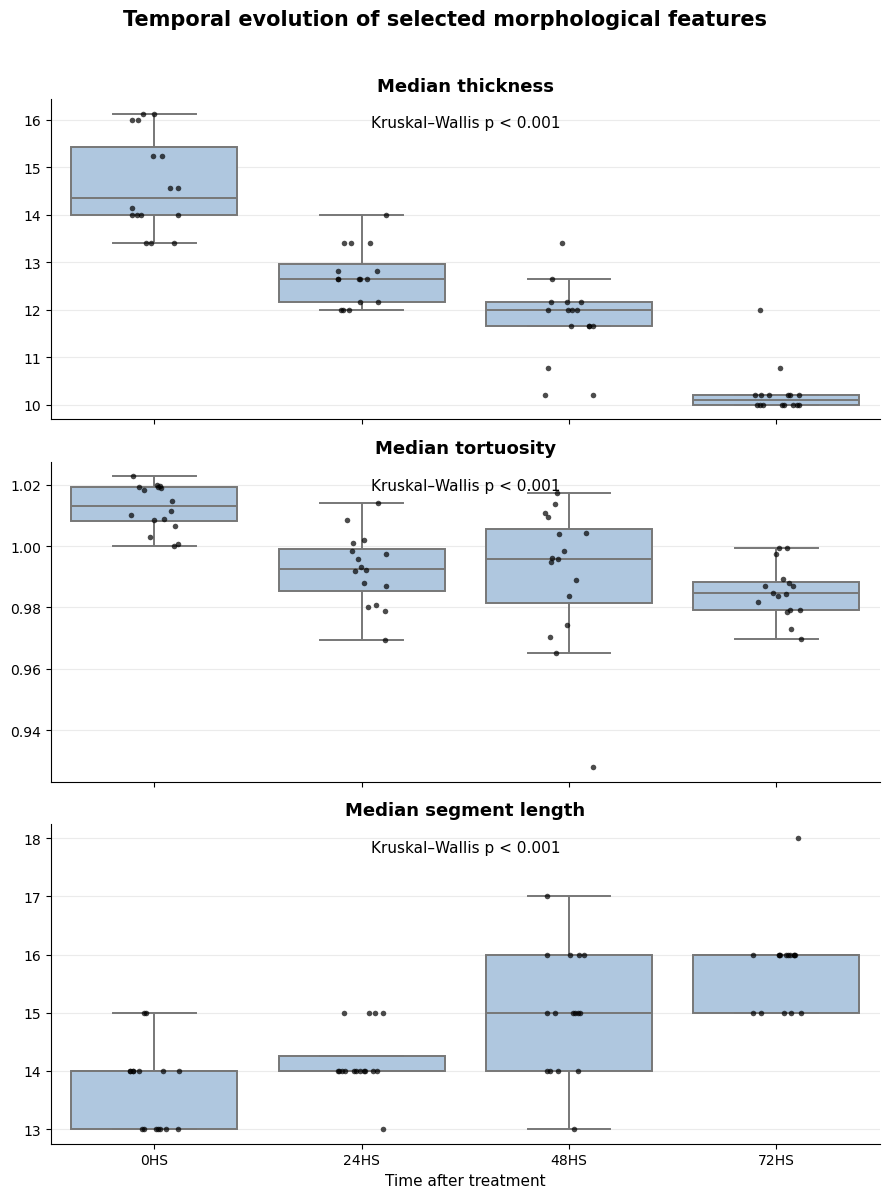

Saved → temporal_feature_boxplots.png


In [16]:
plot_temporal_feature_boxplots(df_temporal)

## Rank features

In [18]:
import importlib
import temporal.feature_selection_temporal as fst

importlib.reload(fst)

<module 'temporal.feature_selection_temporal' from '/Users/alexiagarciaguevara/Documents/ITBA/5 año - 1C/Proyecto Final/Proyecto Final Astrocitos/temporal/feature_selection_temporal.py'>

In [19]:
results_temporal = fst.rank_temporal_features(df_temporal)
fst.print_temporal_report(results_temporal, top_n=15)

  TEMPORAL FEATURE RANKING REPORT (top 15)
 rank               feature importance_tier  composite_score_norm  spearman_rho  sig_spearman  sig_kruskal      trend
    1      median_thickness          🔴 HIGH            100.000000     -0.918096          True         True decreasing
    2        branch_density          🔴 HIGH             99.588681      0.910867          True         True increasing
    3       skeleton_length          🔴 HIGH             99.588681      0.910867          True         True increasing
    4        mean_thickness          🔴 HIGH             94.631684     -0.865475          True         True decreasing
    5 median_segment_length          🔴 HIGH             79.742556      0.747403          True         True increasing
    6   mean_segment_length          🔴 HIGH             77.588503      0.733082          True         True increasing
    7         std_thickness          🔴 HIGH             73.790493     -0.714168          True         True decreasing
    8        

## Prunning by correlation with HIGH features

In [20]:
high_temporal = results_temporal[results_temporal["importance_tier"] == "🔴 HIGH"]["feature"].tolist()
print(high_temporal)

['median_thickness', 'branch_density', 'skeleton_length', 'mean_thickness', 'median_segment_length', 'mean_segment_length', 'std_thickness']


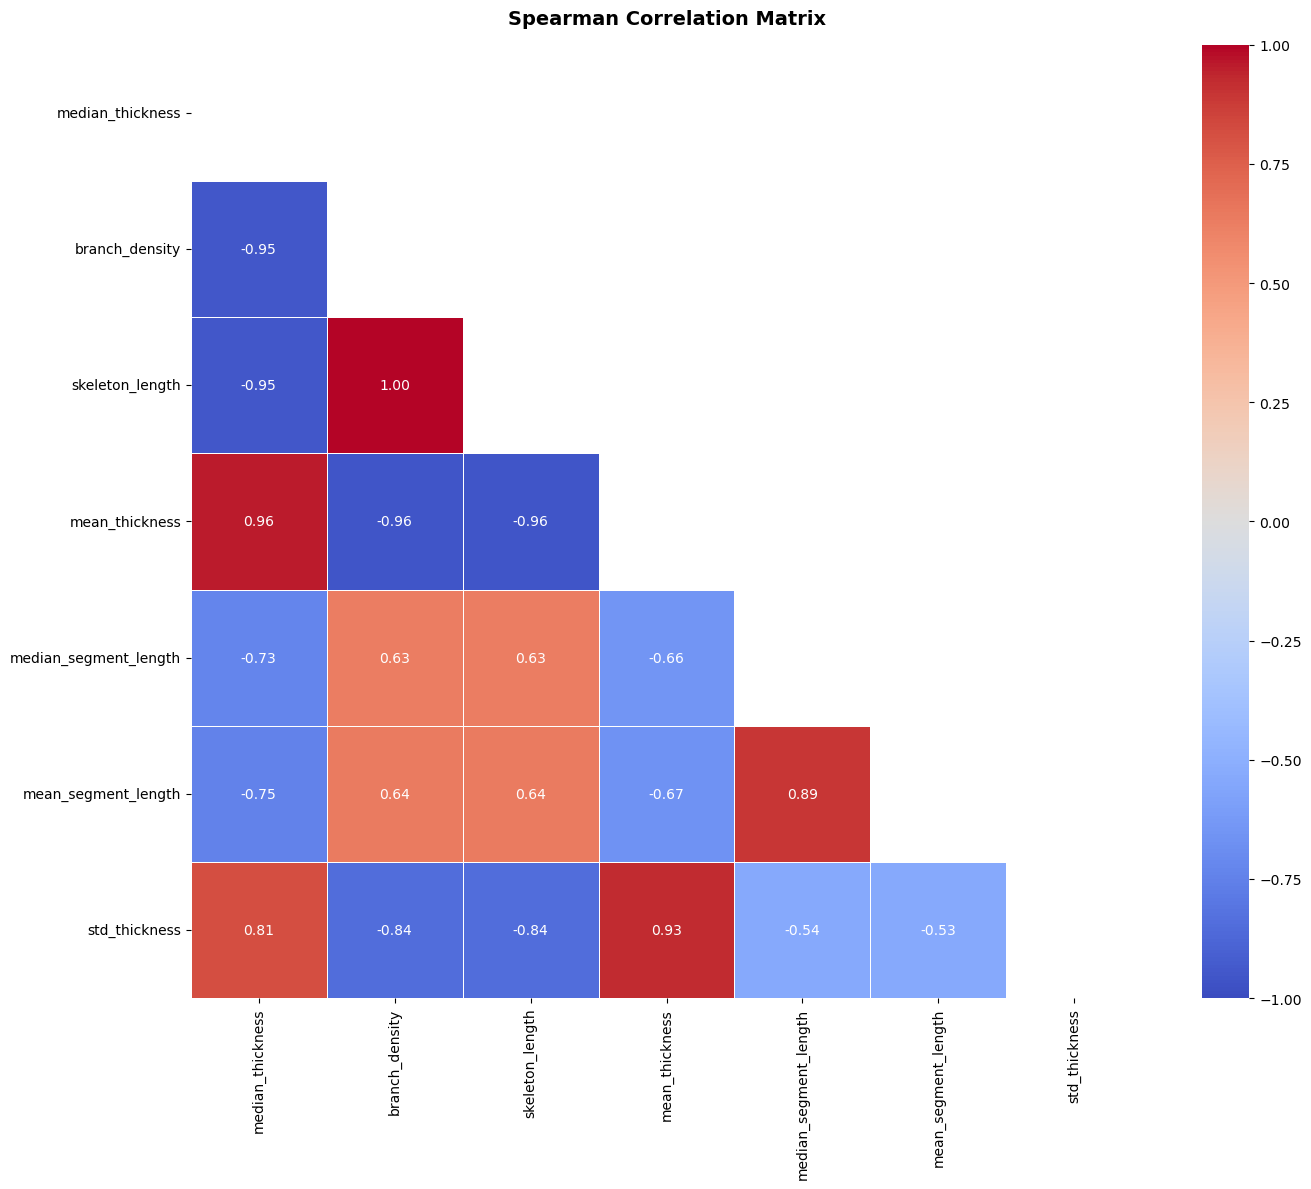

[Step 2] Correlation matrix saved → correlation_matrix.png

[Step 2] Pairs with |r| > 0.85:
            feature_a           feature_b  spearman_r  score_a  score_b                  kept             dropped
       branch_density     skeleton_length      1.0000    99.59    99.59        branch_density     skeleton_length
       branch_density      mean_thickness     -0.9596    99.59    94.63        branch_density      mean_thickness
      skeleton_length      mean_thickness     -0.9596    99.59    94.63       skeleton_length      mean_thickness
     median_thickness      mean_thickness      0.9590   100.00    94.63      median_thickness      mean_thickness
     median_thickness      branch_density     -0.9502   100.00    99.59      median_thickness      branch_density
     median_thickness     skeleton_length     -0.9502   100.00    99.59      median_thickness     skeleton_length
       mean_thickness       std_thickness      0.9257    94.63    73.79        mean_thickness       std_thickn

In [21]:
import feature_selection_pipeline as fsp

pruned_temporal, corr_pairs_temporal = fsp.prune_correlated_features(
    df_temporal,
    high_temporal,
    results_temporal.rename(columns={"composite_score_norm": "composite_score_norm"})
)

print(pruned_temporal)
print(corr_pairs_temporal)

## Features selected in temporal space

In [23]:
import importlib
import temporal.feature_selection_temporal as fst

importlib.reload(fst)

from temporal.feature_selection_temporal import plot_temporal_feature_space

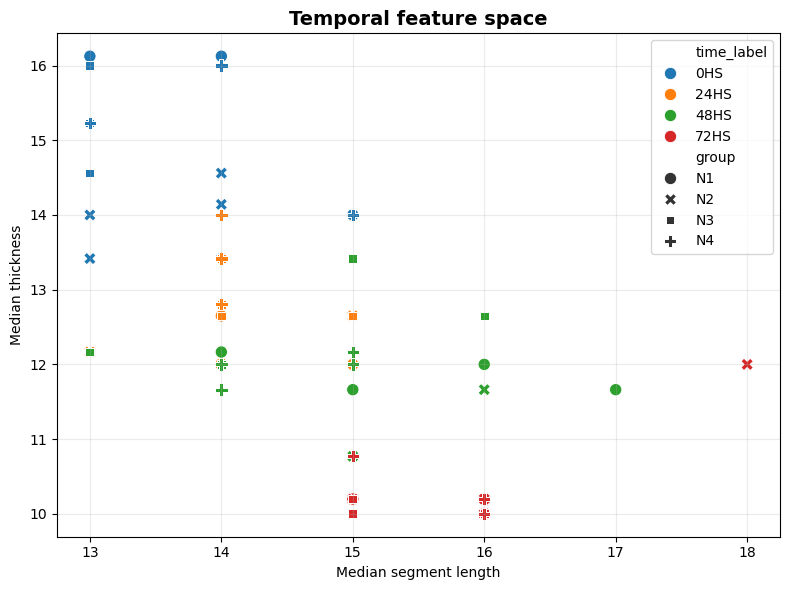

Saved → temporal_feature_space.png


In [24]:
plot_temporal_feature_space(df_temporal)

# Create continuous score

In [ ]:
import temporal.pipeline_temp as pip
importlib.reload(pip)

from temporal.pipeline_temp import add_proinflammatory_score

In [29]:
df_temporal_scored = add_proinflammatory_score(df_temporal)

print(df_temporal_scored[[
    "time_label", "group",
    "median_thickness",
    "median_segment_length",
    "proinflammatory_score"
]].head())

  time_label group  median_thickness  median_segment_length  \
0        0HS    N1         16.124515                   13.0   
1        0HS    N1         16.124515                   14.0   
2        0HS    N1         13.416408                   14.0   
3        0HS    N1         14.000000                   15.0   
4        0HS    N2         13.416408                   13.0   

   proinflammatory_score  
0               0.000000  
1              10.000000  
2              32.108750  
3              37.344356  
4              22.108750  


In [30]:
import temporal.pipeline_temp as pip
importlib.reload(pip)

from temporal.pipeline_temp import plot_proinflammatory_score

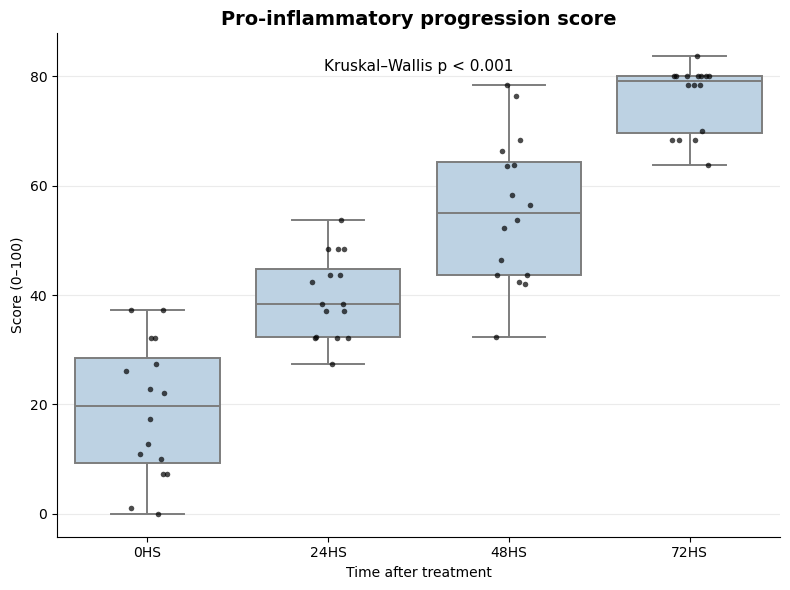

Saved → proinflammatory_score_boxplot.png


In [41]:
plot_proinflammatory_score(df_temporal_scored)

In [32]:
summary_score = df_temporal_scored.groupby("time_label")["proinflammatory_score"].agg(["mean", "std", "median"])
print(summary_score)

                 mean        std     median
time_label                                 
0HS         19.002656  12.400962  19.726553
24HS        39.710837   7.556206  38.372896
48HS        55.521244  13.307582  55.052272
72HS        76.105165   6.048622  79.191613


In [33]:
df_temporal_scored.to_csv("features_dataset_temporal_scored.csv", index=False)

In [42]:
summary_score.to_csv("temporal_score_summary.csv")

# Save temporal score model

In [36]:
import importlib
from temporal import pipeline_temp

importlib.reload(pipeline_temp)

temporal_metadata = pipeline_temp.save_temporal_score_model(df_temporal_scored)
print(temporal_metadata)

Temporal score metadata guardada en: temporal_score_metadata.joblib
{'features': ['median_thickness', 'median_segment_length'], 'thickness_min': 10.0, 'thickness_max': 16.1245154965971, 'segment_min': 13.0, 'segment_max': 18.0, 'score_formula': '0.5 * (1 - thickness_norm) + 0.5 * segment_length_norm', 'score_range': [0, 100], 'categories': {'low': [0, 25], 'mild': [25, 50], 'moderate': [50, 75], 'high': [75, 100]}, 'task': 'temporal_proinflammatory_progression'}


# Probamos con imagen conocida

In [37]:
new_img = temporal_dataset["48HS"]["N2"][0]["image"]

result_temp = pipeline_temp.predict_temporal_progression_score(new_img)

print("Score:", result_temp["score"])
print("Category:", result_temp["category"])
print("Score features:", result_temp["score_features"])

Score: 66.432365216367
Category: moderate inflammatory morphology
Score features: {'median_thickness': 11.661903789690601, 'median_segment_length': 16.0}


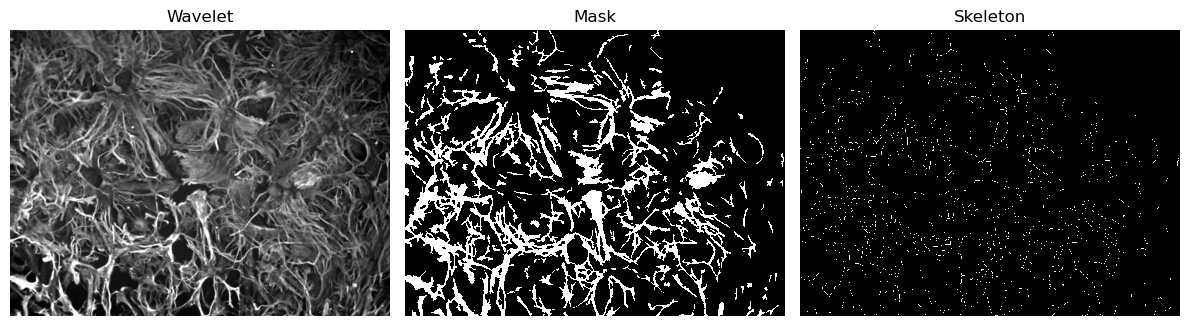

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(result_temp["wavelet"], cmap="gray")
axes[0].set_title("Wavelet")

axes[1].imshow(result_temp["mask"], cmap="gray", vmin=0, vmax=1, interpolation="nearest")
axes[1].set_title("Mask")

axes[2].imshow(result_temp["skeleton"], cmap="gray", vmin=0, vmax=1, interpolation="nearest")
axes[2].set_title("Skeleton")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [39]:
import importlib
from temporal import pipeline_temp

importlib.reload(pipeline_temp)

from temporal.pipeline_temp import test_temporal_progression_all_groups

In [40]:
df_all_progression = test_temporal_progression_all_groups(
    temporal_dataset,
    image_idx=0
)

  time_label group  image_idx   image_name      score  \
0        0HS    N1          0   Image2.tif   0.000000   
1       24HS    N1          0  Image14.tif  43.672178   
2       48HS    N1          0  Image26.tif  76.432365   
3       72HS    N1          0  Image38.tif  80.000000   

                       category  median_thickness  median_segment_length  
0   low inflammatory morphology         16.124515                   13.0  
1  mild inflammatory morphology         12.000000                   14.0  
2  high inflammatory morphology         11.661904                   17.0  
3  high inflammatory morphology         10.000000                   16.0  

¿El score sube progresivamente?
True
  time_label group  image_idx    image_name      score  \
0        0HS    N2          0   Image98.tif  22.108750   
1       24HS    N2          0  Image110.tif  43.672178   
2       48HS    N2          0  Image122.tif  66.432365   
3       72HS    N2          0  Image134.tif  80.000000   

          